# Stage 4: Image Preprocessing

## Objective

Prepare microbial images for deep learning model training.

Tasks:

1. Verify valid images
2. Skip corrupted images
3. Create labels 
4. label Encoding
5. Resize images
6. Normalize pixel values
7. Train-test split

### Task 1: Verify Valid Images

Total images
Valid images
Corrupted images

In [2]:
# ============================================================
# Stage 4: Verify Dataset Images
#
# Purpose:
# Count total images, valid images and corrupted images.
# ============================================================

# Import required libraries
import os
from PIL import Image

# Dataset path
dataset_path = "../archive"

# Store total image count
total_images = 0

# Store valid image count
valid_images = 0

# Store corrupted image count
corrupted_images = 0

# Traverse dataset folders
for species in os.listdir(dataset_path):

    # Create complete species path
    species_path = os.path.join(dataset_path, species)

    # Skip non-folder items
    if not os.path.isdir(species_path):
        continue

    # Traverse folders recursively
    for root, dirs, files in os.walk(species_path):

        # Check every file
        for file in files:

            # Process TIFF images only
            if file.lower().endswith(".tif"):

                # Increase total image count
                total_images += 1

                try:

                    # Create image path
                    image_path = os.path.join(root, file)

                    # Open image
                    image = Image.open(image_path)

                    # Verify image integrity
                    image.verify()

                    # Increase valid image count
                    valid_images += 1

                except Exception:

                    # Increase corrupted image count
                    corrupted_images += 1

# Print final report
print("DATASET VERIFICATION REPORT")
print()

print("Total Images     :", total_images)
print("Valid Images     :", valid_images)
print("Corrupted Images :", corrupted_images)

DATASET VERIFICATION REPORT

Total Images     : 689
Valid Images     : 689
Corrupted Images : 0


## Observation

Dataset verification was completed successfully.

Results:

- Total Images: 689
- Valid Images: 689
- Corrupted Images: 0

All images are valid and ready for preprocessing.

In [3]:
# ============================================================
# Stage 4: Create Image Paths and Labels
#
# Purpose:
# Collect image paths and corresponding species labels.
# ============================================================

# Import required libraries
import os

# Dataset path
dataset_path = "../archive"

# Store image paths
image_paths = []

# Store labels
labels = []

# Traverse species folders
for species in os.listdir(dataset_path):

    # Create complete species path
    species_path = os.path.join(dataset_path, species)

    # Skip non-folder items
    if not os.path.isdir(species_path):
        continue

    # Traverse folders recursively
    for root, dirs, files in os.walk(species_path):

        # Check every file
        for file in files:

            # Process TIFF images only
            if file.lower().endswith(".tif"):

                # Create complete image path
                image_path = os.path.join(root, file)

                # Store image path
                image_paths.append(image_path)

                # Store species label
                labels.append(species)

# Print dataset information
print("Total Image Paths :", len(image_paths))
print("Total Labels      :", len(labels))

# Display first 5 samples
for i in range(5):

    print()
    print("Image :", image_paths[i])
    print("Label :", labels[i])

Total Image Paths : 689
Total Labels      : 689

Image : ../archive/Proteus/Proteus_0008.tif
Label : Proteus

Image : ../archive/Proteus/Proteus_0020.tif
Label : Proteus

Image : ../archive/Proteus/Proteus_0009.tif
Label : Proteus

Image : ../archive/Proteus/Proteus_0019.tif
Label : Proteus

Image : ../archive/Proteus/Proteus_0018.tif
Label : Proteus


### Verify

In [4]:
# Print unique species count

print("Total Unique Species:", len(set(labels)))

print()

# Print all species names
for species in sorted(set(labels)):
    print(species)

Total Unique Species: 33

Acinetobacter.baumanii
Actinomyces.israeli
Bacteroides.fragilis
Bifidobacterium.spp
Candida.albicans
Clostridium.perfringens
Enterococcus.faecalis
Enterococcus.faecium
Escherichia.coli
Fusobacterium
Lactobacillus.casei
Lactobacillus.crispatus
Lactobacillus.delbrueckii
Lactobacillus.gasseri
Lactobacillus.jehnsenii
Lactobacillus.johnsonii
Lactobacillus.paracasei
Lactobacillus.plantarum
Lactobacillus.reuteri
Lactobacillus.rhamnosus
Lactobacillus.salivarius
Listeria.monocytogenes
Micrococcus.spp
Neisseria.gonorrhoeae
Porfyromonas.gingivalis
Propionibacterium.acnes
Proteus
Pseudomonas.aeruginosa
Staphylococcus.aureus
Staphylococcus.epidermidis
Staphylococcus.saprophiticus
Streptococcus.agalactiae
Veionella


In [5]:
# Show first 20 labels

for i in range(25):
    print(labels[i])

Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Proteus
Lactobacillus.plantarum
Lactobacillus.plantarum
Lactobacillus.plantarum
Lactobacillus.plantarum
Lactobacillus.plantarum


In [6]:
# Total unique species

print(len(set(labels)))

33


### Label Encoding Kya Hota Hai?
Abhi labels text format me hain:
Proteus
Escherichia.coli
Staphylococcus.aureus
...
CNN text nahi samajhta.
Hume convert karna padega:


# Label Encoding

In [7]:
# ============================================================
# Stage 4: Label Encoding
#
# Purpose:
# Convert species names into numerical labels that can
# be used by deep learning models.
# ============================================================

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
label_encoder = LabelEncoder()

# Convert text labels into numbers
encoded_labels = label_encoder.fit_transform(labels)

# Print total classes
print("Total Classes :", len(label_encoder.classes_))

# Display first 10 label mappings
print("\nFirst 10 Encoded Labels:\n")

for i in range(10):

    print(
        labels[i],
        " ---> ",
        encoded_labels[i]
    )
    # Loop through all species

    for index, class_name in enumerate(label_encoder.classes_):
 
         print(index, " ---> ", class_name)

Total Classes : 33

First 10 Encoded Labels:

Proteus  --->  26
0  --->  Acinetobacter.baumanii
1  --->  Actinomyces.israeli
2  --->  Bacteroides.fragilis
3  --->  Bifidobacterium.spp
4  --->  Candida.albicans
5  --->  Clostridium.perfringens
6  --->  Enterococcus.faecalis
7  --->  Enterococcus.faecium
8  --->  Escherichia.coli
9  --->  Fusobacterium
10  --->  Lactobacillus.casei
11  --->  Lactobacillus.crispatus
12  --->  Lactobacillus.delbrueckii
13  --->  Lactobacillus.gasseri
14  --->  Lactobacillus.jehnsenii
15  --->  Lactobacillus.johnsonii
16  --->  Lactobacillus.paracasei
17  --->  Lactobacillus.plantarum
18  --->  Lactobacillus.reuteri
19  --->  Lactobacillus.rhamnosus
20  --->  Lactobacillus.salivarius
21  --->  Listeria.monocytogenes
22  --->  Micrococcus.spp
23  --->  Neisseria.gonorrhoeae
24  --->  Porfyromonas.gingivalis
25  --->  Propionibacterium.acnes
26  --->  Proteus
27  --->  Pseudomonas.aeruginosa
28  --->  Staphylococcus.aureus
29  --->  Staphylococcus.epidermidis

In [8]:
print(type(labels))

<class 'list'>


In [9]:
import sys

print(sys.executable)

/Users/viveksingh/AMR_PROJECT/venv/bin/python


# Image Resizing

In [10]:
# ============================================================
# Stage 4: Resize Images
#
# Purpose:
# Load images and resize them to 224x224 pixels.
# ============================================================

# Import required libraries
import os
from PIL import Image
import numpy as np

# Dataset path
dataset_path = "../archive"

# Store resized images
resized_images = []

# Store labels
image_labels = []

# Target image size
TARGET_SIZE = (224, 224)

# Traverse dataset folders
for species in os.listdir(dataset_path):

    # Create species folder path
    species_path = os.path.join(dataset_path, species)

    # Skip non-folder items
    if not os.path.isdir(species_path):
        continue

    # Traverse folders recursively
    for root, dirs, files in os.walk(species_path):

        # Process every file
        for file in files:

            # Process TIFF files only
            if file.lower().endswith(".tif"):

                try:

                    # Create complete image path
                    image_path = os.path.join(root, file)

                    # Open image
                    image = Image.open(image_path)

                    # Convert image to RGB
                    image = image.convert("RGB")

                    # Resize image
                    image = image.resize(TARGET_SIZE)

                    # Convert image to NumPy array
                    image_array = np.array(image)

                    # Store image array
                    resized_images.append(image_array)

                    # Store label
                    image_labels.append(species)

                except Exception:

                    # Skip problematic images
                    continue

# Convert list into NumPy array
resized_images = np.array(resized_images)

# Print dataset shape
print("Dataset Shape :", resized_images.shape)

# Print total labels
print("Total Labels :", len(image_labels))

Dataset Shape : (689, 224, 224, 3)
Total Labels : 689


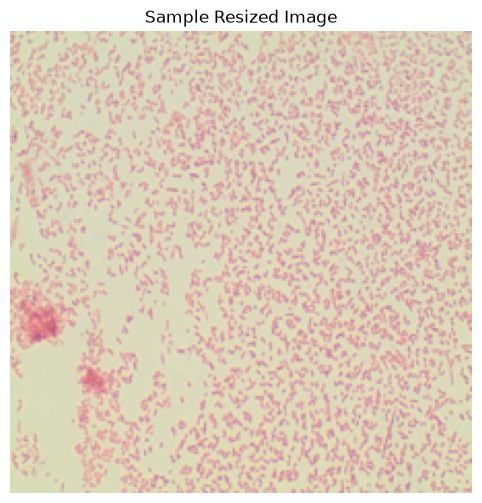

Image Shape : (224, 224, 3)


In [11]:
# ============================================================
# Stage 4: Verify Resized Image
#
# Purpose:
# Display one resized image and verify its dimensions.
# ============================================================

# Import required libraries
import matplotlib.pyplot as plt

# Display first resized image
plt.figure(figsize=(6, 6))

plt.imshow(resized_images[0])

plt.title("Sample Resized Image")

plt.axis("off")

plt.show()

# Print image shape
print("Image Shape :", resized_images[0].shape)

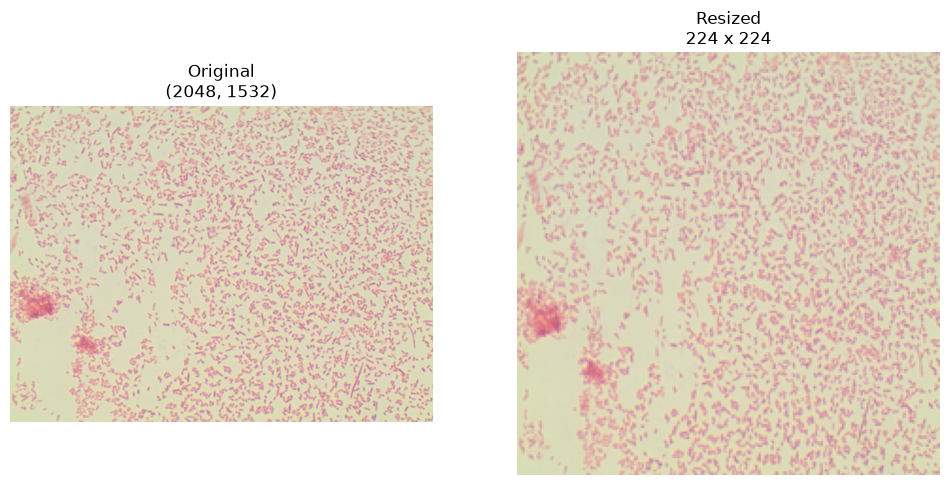

Original Size : (2048, 1532)
Resized Size  : (224, 224)


In [12]:
# ============================================================
# Compare Original and Resized Image
# ============================================================

# Import required libraries
from PIL import Image
import matplotlib.pyplot as plt

# Select first image path
sample_image_path = image_paths[0]

# Open original image
original_image = Image.open(sample_image_path)

# Convert to RGB
original_image = original_image.convert("RGB")

# Resize image
resized_image = original_image.resize((224, 224))

# Create figure
plt.figure(figsize=(12, 6))

# Show original image
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Original\n{original_image.size}")
plt.axis("off")

# Show resized image
plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title("Resized\n224 x 224")
plt.axis("off")

plt.show()

# Print dimensions
print("Original Size :", original_image.size)
print("Resized Size  :", resized_image.size)

## Observation

All images were successfully resized to 224 × 224 pixels.

The resized images were converted into NumPy arrays and are ready for normalization and model training.

# Image Normalization

In [13]:
# ============================================================
# Stage 4: Image Normalization
#
# Purpose:
# Convert pixel values from 0-255 range
# to 0-1 range.
# ============================================================

# Convert image array to float32
resized_images = resized_images.astype("float32")

# Normalize pixel values
normalized_images = resized_images / 255.0

# Print dataset shape
print("Dataset Shape :", normalized_images.shape)

# Print minimum pixel value
print("Minimum Pixel Value :", normalized_images.min())

# Print maximum pixel value
print("Maximum Pixel Value :", normalized_images.max())

Dataset Shape : (689, 224, 224, 3)
Minimum Pixel Value : 0.08627451
Maximum Pixel Value : 1.0


In [14]:
# ============================================================
# Verify Normalized Image
# ============================================================

# Display shape of first image
print("Image Shape :", normalized_images[0].shape)

# Display first pixel value
print("First Pixel :", normalized_images[0][0][0])

# Display data type
print("Data Type :", normalized_images.dtype)

Image Shape : (224, 224, 3)
First Pixel : [0.8666667 0.7372549 0.6745098]
Data Type : float32


## Observation

All images were normalized successfully.

Pixel values were scaled from the range [0,255] to [0,1].

Normalization helps improve deep learning model convergence and training stability.

# Train-Test Split


In [15]:
# ============================================================
# Stage 4: Train-Test Split
#
# Purpose:
# Split dataset into training and testing sets.
# ============================================================

# Import required library
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    normalized_images,      # Input images
    encoded_labels,         # Encoded labels
    test_size=0.20,         # 20% testing data
    random_state=42,        # Reproducible results
    stratify=encoded_labels # Maintain class balance
)

# Print dataset shapes
print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (551, 224, 224, 3)
Testing Images  : (138, 224, 224, 3)

Training Labels : (551,)
Testing Labels  : (138,)


Why stratify=encoded_labels?
Bahut important hai.
Without stratify:
Kuch species training me zyada
Kuch testing me kam
ho sakti hain.
With stratify:
Har species ka proportion
train aur test dono me maintain rahega.

In [16]:
# ============================================================
# Verify Final Dataset
# ============================================================

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print()

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

print()

print("Total Classes :", len(label_encoder.classes_))

X_train Shape : (551, 224, 224, 3)
X_test Shape  : (138, 224, 224, 3)

y_train Shape : (551,)
y_test Shape  : (138,)

Total Classes : 33


In [18]:
# ============================================================
# Verify Class Distribution After Train-Test Split
#
# Purpose:
# Check number of samples from each class in
# training and testing datasets.
# ============================================================

# Import required library
import numpy as np

# Count training samples
train_counts = np.bincount(y_train)

# Count testing samples
test_counts = np.bincount(y_test)

# Display counts for every class
for i, class_name in enumerate(label_encoder.classes_):

    print(
        f"{class_name:35s}",
        f"Train = {train_counts[i]:2d}",
        f"Test = {test_counts[i]:2d}"
    )

Acinetobacter.baumanii              Train = 16 Test =  4
Actinomyces.israeli                 Train = 18 Test =  5
Bacteroides.fragilis                Train = 18 Test =  5
Bifidobacterium.spp                 Train = 19 Test =  4
Candida.albicans                    Train = 16 Test =  4
Clostridium.perfringens             Train = 18 Test =  5
Enterococcus.faecalis               Train = 16 Test =  4
Enterococcus.faecium                Train = 16 Test =  4
Escherichia.coli                    Train = 16 Test =  4
Fusobacterium                       Train = 18 Test =  5
Lactobacillus.casei                 Train = 16 Test =  4
Lactobacillus.crispatus             Train = 16 Test =  4
Lactobacillus.delbrueckii           Train = 16 Test =  4
Lactobacillus.gasseri               Train = 16 Test =  4
Lactobacillus.jehnsenii             Train = 16 Test =  4
Lactobacillus.johnsonii             Train = 16 Test =  4
Lactobacillus.paracasei             Train = 16 Test =  4
Lactobacillus.plantarum        

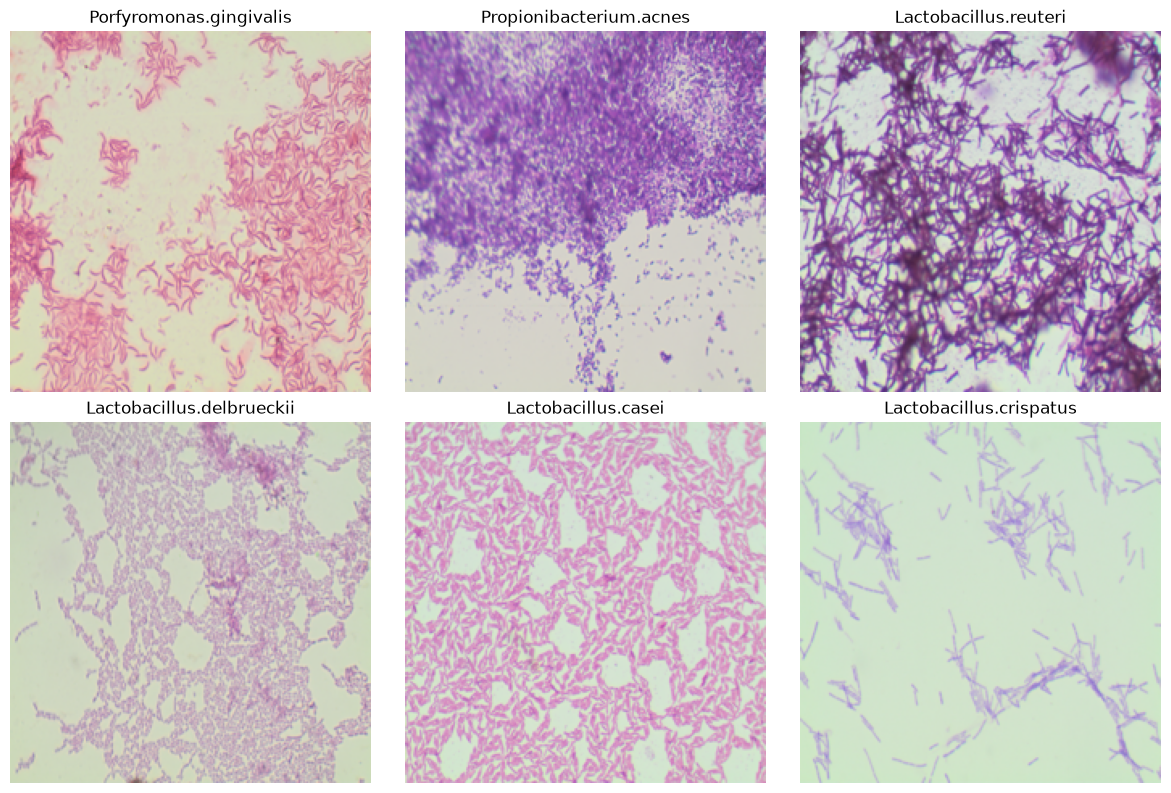

In [19]:
# ============================================================
# Display Sample Training Images
#
# Purpose:
# Verify images and labels after preprocessing.
# ============================================================

# Import required library
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12, 8))

# Display first 6 images
for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(X_train[i])

    plt.title(
        label_encoder.inverse_transform([y_train[i]])[0]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# Final Dataset Sanity Check
#
# Purpose:
# Verify that dataset is ready for CNN training.
# ============================================================

# Print training data shape
print("X_train Shape :", X_train.shape)

# Print testing data shape
print("X_test Shape  :", X_test.shape)

print()

# Print label shape
print("y_train Shape :", y_train.shape)

print("y_test Shape  :", y_test.shape)

print()

# Print pixel range
print("Minimum Pixel Value :", X_train.min())

print("Maximum Pixel Value :", X_train.max())

print()

# Print total classes
print("Total Classes :", len(label_encoder.classes_))

X_train Shape : (551, 224, 224, 3)
X_test Shape  : (138, 224, 224, 3)

y_train Shape : (551,)
y_test Shape  : (138,)

Minimum Pixel Value : 0.08627451
Maximum Pixel Value : 1.0

Total Classes : 33


# Stage 4 Summary

Image preprocessing was completed successfully.

Steps performed:

1. Dataset verification
2. Label generation
3. Label encoding
4. Image resizing (224 × 224)
5. Pixel normalization
6. Train-test split (80:20)

Final Dataset:

- Training Images: 551
- Testing Images: 138
- Total Classes: 33

The dataset is ready for CNN model training.

## Observation

The dataset was successfully split into training and testing sets.

- 80% data used for training.
- 20% data reserved for testing.
- Class distribution was preserved using stratified sampling.

The dataset is now ready for CNN model development.